## Network Builder - Parts 1 and 2
### Skill-Based Occupational Network Construction
This notebook cleans ESCO occupation-skill data, builds the occupation-skill matrix, computes Jaccard similarity, and constructs the occupational network.

## 1. Import Libraries

We begin by importing the main libraries used for data manipulation, similarity computation, network construction, and visualization.

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import defaultdict

import networkx as nx
from sklearn.metrics import pairwise_distances

## 2. Load Data

We load the ESCO occupation-skill dataset, which contains the relationships between occupations and the skills associated with them.

In [2]:
df = pd.read_csv("occupationSkillRelations_en.csv")
df.head()

,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...
3,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...,coordinate with creative departments
4,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...,adapt to artists' creative demands


In [3]:
df.columns.tolist()

['occupationUri',
 'occupationLabel',
 'relationType',
 'skillType',
 'skillUri',
 'skillLabel']

In [5]:
df.shape

(126051, 6)

## 3. Missing Values Check

Before constructing the network, we check whether the relevant variables contain missing values.

In [6]:
(df.isnull().sum() / len(df)) * 100

occupationUri      0.000000
occupationLabel    0.000000
relationType       0.000000
skillType          0.046806
skillUri           0.000000
skillLabel         0.000000
dtype: float64

In [7]:
df[['occupationLabel', 'skillLabel']].isnull().sum()

occupationLabel    0
skillLabel         0
dtype: int64

## 4. Data Cleaning and Preparation

We clean the dataset by keeping only the relevant variables (occupation and skills) and removing duplicate entries. This ensures that each occupation-skill relationship is represented only once before constructing the network.

In [8]:
df_clean = df[['occupationLabel', 'skillLabel']].drop_duplicates()
df_clean.head()

,occupationLabel,skillLabel
0,technical director,theatre techniques
1,technical director,organise rehearsals
2,technical director,write risk assessment on performing arts produ...
3,technical director,coordinate with creative departments
4,technical director,adapt to artists' creative demands


In [9]:
df_clean.shape

(126051, 2)

## 5. Occupation-Skill Matrix Construction

We construct a binary matrix where rows represent occupations and columns represent skills. A value of 1 indicates that an occupation requires a given skill.

In [10]:
matrix = pd.crosstab(df_clean['occupationLabel'], df_clean['skillLabel'])
matrix.iloc[:5, :5]

skillLabel,3D body scanning technologies,3D lighting,3D modelling,3D printing process,3D texturing
occupationLabel,,,,,
3D animator,0,1,0,0,1
3D modeller,0,1,0,1,1
3D printing technician,0,0,1,1,0
ATM repair technician,0,0,0,0,0
EU funds manager,0,0,0,0,0


In [11]:
matrix.shape

(3039, 13475)

## 6. Jaccard Similarity Computation

We compute similarity between occupations using the Jaccard index. This measure captures the proportion of shared skills between two occupations relative to the total number of skills they possess.

Higher similarity implies that two occupations require similar skill sets and therefore represent more feasible transitions.

In [12]:
# Convert matrix to binary (True/False)
binary_matrix = matrix.astype(bool)

# Convert to numpy array
binary_array = binary_matrix.to_numpy()

# Compute Jaccard distance
jaccard_dist = pairwise_distances(binary_array, metric='jaccard')

# Convert distance to similarity
jaccard_sim = 1 - jaccard_dist

# Check result
print(jaccard_sim.shape)

(3039, 3039)


## 7. Threshold Sensitivity Analysis

To validate the network construction, we analyze how different similarity thresholds affect the structure of the occupational network. Lower thresholds produce denser networks, while higher thresholds retain only stronger and more meaningful connections.

This analysis helps justify the choice of the threshold used in the main network.

In [13]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for tau in thresholds:
    adj_tau = (jaccard_sim > tau).astype(int)
    np.fill_diagonal(adj_tau, 0)

    G_tau = nx.from_numpy_array(adj_tau)

    n_edges = G_tau.number_of_edges()
    density = nx.density(G_tau)
    n_components = nx.number_connected_components(G_tau)
    largest_cc = max(nx.connected_components(G_tau), key=len)
    largest_cc_size = len(largest_cc)

    results.append({
        "threshold": tau,
        "edges": n_edges,
        "density": density,
        "n_components": n_components,
        "largest_component_size": largest_cc_size
    })

results_df = pd.DataFrame(results)
results_df

,threshold,edges,density,n_components,largest_component_size
0,0.1,66870,0.014486,50,2977
1,0.2,28813,0.006242,445,1751
2,0.3,14103,0.003055,1025,416
3,0.4,8635,0.001871,1627,84
4,0.5,6412,0.001389,2044,44


### Threshold Sensitivity Plot

We visualize how the size of the largest connected component changes as the similarity threshold increases.

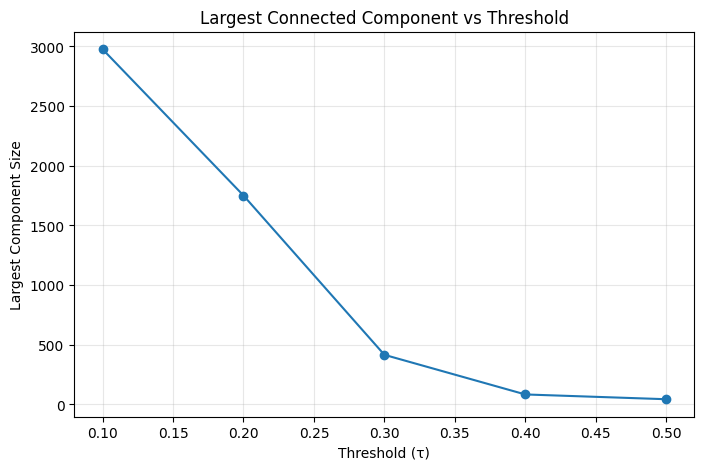

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["largest_component_size"], marker="o")
plt.title("Largest Connected Component vs Threshold")
plt.xlabel("Threshold (τ)")
plt.ylabel("Largest Component Size")
plt.grid(True, alpha=0.3)
plt.show()


The threshold sensitivity analysis shows that lower thresholds produce highly connected networks, while higher thresholds lead to increasingly fragmented structures.

At higher thresholds, the network becomes overly sparse, with the largest connected component including only a small fraction of occupations. This indicates that the similarity criterion is too restrictive, eliminating many plausible connections between occupations and limiting the ability to capture meaningful transition pathways. As the threshold is reduced, connectivity increases but we risk overestimating similarity across occupations. 

**At τ = 0.2**, the network retains a large connected core while also revealing several substantial secondary components. This indicates a more structured occupational space, where transitions are possible within and across major clusters but still constrained by meaningful differences in skill requirements. Therefore, τ = 0.2 is preferred as it balances connectivity with structural differentiation, providing a more realistic representation of occupational mobility.

## 8. Network Construction

We construct a network where nodes represent occupations and edges connect occupations with similarity above a given threshold τ. This allows us to focus on meaningful transitions between occupations.

In [15]:
# Set threshold
threshold = 0.2
occ_labels = matrix.index.tolist()

# Build weighted graph with occupation labels as node names
G = nx.Graph()
G.add_nodes_from(occ_labels)

rows, cols = np.where(jaccard_sim > threshold)
for r, c in zip(rows, cols):
    if r < c:  # avoid duplicates and self-loops
        G.add_edge(occ_labels[r], occ_labels[c], weight=jaccard_sim[r, c])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3039
Number of edges: 28813


## Summary

In this section, we cleaned the ESCO data, constructed the occupation-skill matrix, computed occupational similarity using the Jaccard index, built the occupational network, and justified the selection of the threshold used in the main analysis.

In [118]:
# Export threshold sensitivity results
#results_df.to_csv("threshold_sensitivity_results.csv", index=False)

# Export Jaccard similarity matrix
#pd.DataFrame(jaccard_sim, index=matrix.index, columns=matrix.index).to_csv("jaccard_similarity_matrix.csv")

# Export network edges with weights
#nx.write_graphml(G, "occupational_network_tau03.graphml")

## 10. Network Overview


We compute basic descriptive statistics of the occupational network. Specifically, we measure the number of nodes (occupations), the number of edges (similarity-based connections), network density (the proportion of possible connections that are realized), and the average degree (average number of connections per occupation).

In [16]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / n_nodes

print("=== Network Overview ===")
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density:.4f}")
print(f"Average degree: {avg_degree:.2f}")

=== Network Overview ===
Number of nodes: 3039
Number of edges: 28813
Density: 0.0062
Average degree: 18.96


The occupational network consists of 3,039 nodes and 28,813 edges, with a density of 0.0062. While the network remains relatively sparse compared to a fully connected graph, this density indicates a moderate level of interconnectedness across occupations. A non-negligible share of occupation pairs exhibit meaningful skill similarity, allowing for multiple potential transition pathways.

The average degree is 18.96, meaning that, on average, each occupation is connected to approximately 19 others. This suggests that many occupations have a substantial but not excessive set of similar alternatives, reflecting meaningful overlap in skill requirements while still preserving differentiation across roles.

## 11. Connectivity Analysis


We analyze the structure of the network by identifying connected components, groups of occupations, that are reachable from one another through paths of similarity links. We also compute the size of the largest connected component and its share of total nodes.

In [17]:
n_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))

largest_cc = max(components, key=len)
largest_cc_size = len(largest_cc)
largest_cc_share = largest_cc_size / n_nodes

print("\n=== Connectivity Analysis ===")
print(f"Number of connected components: {n_components}")
print(f"Largest component size: {largest_cc_size}")
print(f"Share of nodes in largest component: {largest_cc_share:.4f}")


=== Connectivity Analysis ===
Number of connected components: 445
Largest component size: 1751
Share of nodes in largest component: 0.5762


The network contains 445 connected components, indicating a moderate level of fragmentation. The largest connected component includes 1,751 occupations, representing approximately 57.62% of the network.

This suggests that the occupational space is partially integrated, with a large core of interconnected occupations but also a significant number of smaller, separate components. Unlike highly connected networks, where nearly all occupations are reachable, or highly fragmented ones, where transitions are severely limited, this structure reflects a balance between connectivity and segmentation.

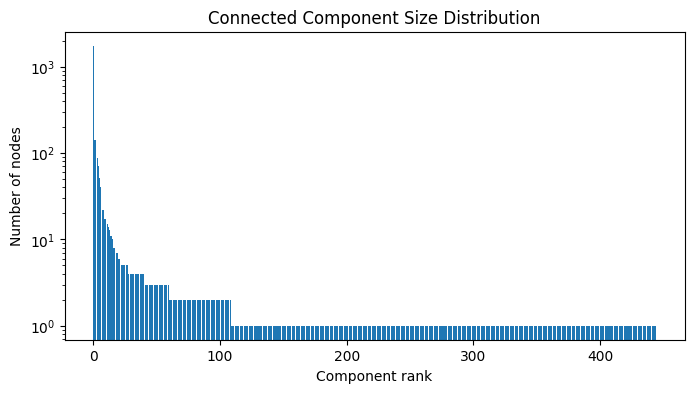

Number of isolated nodes: 336
Component sizes (top 10): [1751, 142, 141, 87, 71, 51, 40, 22, 22, 17]


In [18]:
component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)

plt.figure(figsize=(8, 4))
plt.bar(range(len(component_sizes)), component_sizes)
plt.title("Connected Component Size Distribution")
plt.xlabel("Component rank")
plt.ylabel("Number of nodes")
plt.yscale("log")
plt.show()

print(f"Number of isolated nodes: {sum(1 for s in component_sizes if s == 1)}")
print(f"Component sizes (top 10): {component_sizes[:10]}")

The distribution reveals a big component containing 1,751 nodes, which towers above all other components on the log scale. The second and third largest components contain only 142 and 141 nodes, and the drop-off is steep. Beyond rank ~110, all remaining components are size 1, giving 336 isolated nodes. The network exhibits a clear core-periphery structure, meaning a single dominant cluster has formed, while a substantial fraction of nodes remain in small disconnected subgroups or are entirely isolated.

The presence of several sizable secondary components (e.g., components with over 100 occupations) indicates that the labor market is organized into distinct submarkets or clusters, within which transitions are more feasible. Occupations outside the largest component may represent more specialized roles with limited connectivity to the broader occupational space.

## 12. Degree Distribution 

We examine how connections are distributed across occupations by plotting the degree distribution. This shows how many occupations have few versus many connections.

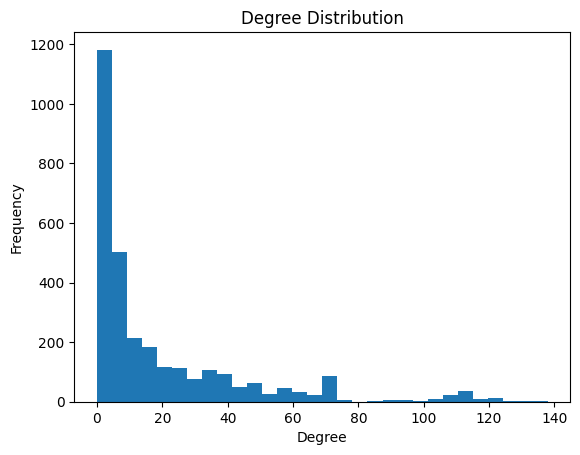

In [19]:
degree_values = list(degrees.values())

plt.figure()
plt.hist(degree_values, bins=30)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

The degree distribution is strongly right-skewed, indicating that most occupations have relatively few connections, while a small number of occupations have a large number of links.

This suggests the presence of hub occupations with broadly transferable skills, which are connected to many other roles and may facilitate transitions across different parts of the network. In contrast, the majority of occupations remain more specialized, with fewer direct connections.

Within this moderately connected network, the uneven distribution of links highlights heterogeneity in transition opportunities, where some occupations occupy central positions with high flexibility, while others remain more constrained within specific segments of the labor market.

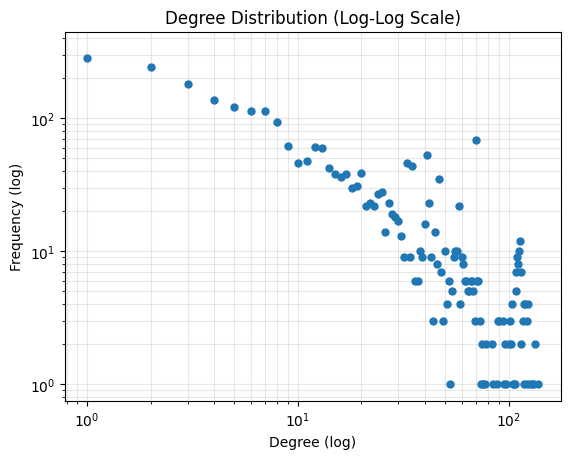

In [132]:
degree_values = list(dict(G.degree()).values())
counts = np.bincount(degree_values)
degrees_x = np.nonzero(counts)[0]
counts_y = counts[degrees_x]

plt.figure()
plt.loglog(degrees_x, counts_y, 'o', markersize=5)
plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

The log-log plot displays a clear negative linear trend, consistent with a heavy-tailed, approximately power-law distribution. Low-degree nodes are abundant, while high-degree nodes exist but are rare, with the maximum degree reaching just above 10². The scatter increases at higher degrees, which is typical for empirical networks of this size. This heterogeneous structure indicates the network is not random, connectivity is highly unequal across nodes, with a small number of hubs and a large majority of lightly connected nodes.

## 13. Network Visualization

To make the network interpretable, we visualize a sample of 100 nodes from the largest connected component. Node size reflects degree (number of connections), and only the most connected nodes are labeled to reduce visual clutter.

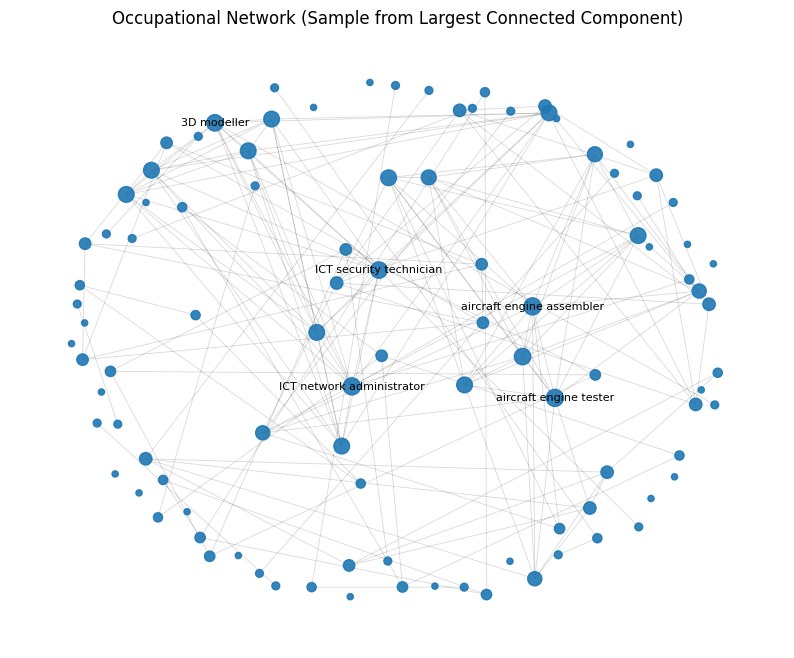

In [20]:
import networkx as nx

# Extract largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

# Take a sample of 100 nodes 
sample_nodes = list(G_lcc.nodes())[:100]
G_vis = G_lcc.subgraph(sample_nodes).copy()

#  Node sizes based on degree
degrees = dict(G_vis.degree())
node_sizes = [degrees[n] * 12 + 20 for n in G_vis.nodes()]

# 4. Label top 5 nodes
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
labels = {n: n for n in top_nodes}

# 5. Layout
pos = nx.spring_layout(G_vis, seed=42, k=0.9)

# 6. Plot
plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(G_vis, pos, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

plt.title("Occupational Network (Sample from Largest Connected Component)")
plt.axis("off")
plt.show()

The visualization reveals a structured and partially interconnected network, consistent with the presence of a large but not dominant connected component. While many occupations are linked through direct or indirect connections, the network does not collapse into a single fully integrated structure.

Within this structure, areas of higher density can be observed, indicating groups of occupations that share similar skill requirements and form cohesive clusters. Larger nodes, representing occupations with higher degree, tend to occupy more central positions and may act as connectors within and across these clusters, facilitating transitions within the broader occupational space.

At the same time, the presence of peripheral and weakly connected nodes reflects occupations with more specialized skill sets, which may face greater barriers to mobility. Overall, the visualization highlights a labor market that is connected but segmented, where mobility is feasible within clusters but not uniformly across all occupations.

## 14. Summary statistics

In [21]:
stats = {
    "Nodes": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "Density": round(nx.density(G), 6),
    "Avg Degree": round(sum(dict(G.degree()).values()) / G.number_of_nodes(), 2),
    "Connected Components": nx.number_connected_components(G),
    "Largest Component (nodes)": len(max(nx.connected_components(G), key=len)),
    "Largest Component (% of total)": round(
        len(max(nx.connected_components(G), key=len)) / G.number_of_nodes() * 100, 2
    ),
    "Max Degree": max(dict(G.degree()).values()),
    "Min Degree": min(dict(G.degree()).values()),
}

pd.DataFrame(stats.items(), columns=["Metric", "Value"])

,Metric,Value
0,Nodes,3039.000000
1,Edges,28813.000000
2,Density,0.006242
3,Avg Degree,18.960000
4,Connected Components,445.000000
5,Largest Component (nodes),1751.000000
6,Largest Component (% of total),57.620000
7,Max Degree,138.000000
8,Min Degree,0.000000


The summary statistics indicate a network that is sparse but meaningfully connected. With 3,039 nodes, 28,813 edges, and a density of 0.0062, only a small share of possible connections are realized, reflecting selective but relevant skill similarities between occupations.

The average degree of 18.96 suggests that occupations have a moderate number of feasible alternatives, while the high maximum degree (138) indicates the presence of hub occupations with broadly transferable skills. In contrast, the existence of isolated nodes (degree 0) highlights highly specialized roles with limited mobility.

Structurally, the network is partially integrated, with 57.62% of occupations in the largest connected component and the remainder distributed across smaller components. This suggests a labor market composed of a large core alongside distinct submarkets, where mobility is possible but uneven across occupations.

## 15. Community Detection

We apply the greedy modularity maximization algorithm to detect communities within the occupational network — groups of occupations that are more densely connected to each other than to the rest of the network. We compute the modularity score to assess the quality of the partition and inspect the size distribution and top occupations of the identified communities.

In [22]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(G, weight='weight'))
n_communities = len(communities)
print(f"Number of communities detected: {n_communities}")

mod_score = modularity(G, communities, weight='weight')
print(f"Modularity score: {mod_score:.4f}")

sizes = sorted([len(c) for c in communities], reverse=True)
print(f"Largest community: {sizes[0]} occupations")
print(f"Smallest community: {sizes[-1]} occupations")
print(f"Top 10 community sizes: {sizes[:10]}")

Number of communities detected: 479
Modularity score: 0.8944
Largest community: 210 occupations
Smallest community: 1 occupations
Top 10 community sizes: [210, 156, 144, 128, 107, 100, 99, 83, 79, 78]


The algorithm identifies 479 communities with a modularity score of 0.8944. This exceptionally high modularity indicates a strongly structured network, where occupations cluster around distinct and internally cohesive skill sets. The largest community contains 210 occupations, while the smallest consists of a single occupation, reflecting a highly skewed distribution of community sizes similar to what was observed in the degree distribution and connected component analysis.

In [23]:
communities_sorted = sorted(communities, key=len, reverse=True)

print("=== Top Occupations per Community (Top 5 Communities) ===")
for i, comm in enumerate(communities_sorted[:5]):
    comm_list = list(comm)
    subgraph = G.subgraph(comm_list)
    internal_deg = dict(subgraph.degree())
    top_occs = sorted(internal_deg, key=internal_deg.get, reverse=True)[:5]
    print(f"\nCommunity {i+1} ({len(comm)} occupations):")
    for occ in top_occs:
        print(f"  - {occ} (internal degree: {internal_deg[occ]})")

=== Top Occupations per Community (Top 5 Communities) ===

Community 1 (210 occupations):
  - mathematics lecturer (internal degree: 136)
  - university literature lecturer (internal degree: 132)
  - healthcare specialist lecturer (internal degree: 132)
  - engineering lecturer (internal degree: 129)
  - modern languages lecturer (internal degree: 128)

Community 2 (156 occupations):
  - nailing machine operator (internal degree: 96)
  - wood boring machine operator (internal degree: 77)
  - laser marking machine operator (internal degree: 73)
  - riveter (internal degree: 72)
  - plasma cutting machine operator (internal degree: 70)

Community 3 (144 occupations):
  - container equipment design engineer (internal degree: 29)
  - product development engineering drafter (internal degree: 28)
  - rotating equipment engineer (internal degree: 27)
  - aerospace engineering drafter (internal degree: 27)
  - rolling stock engineering drafter (internal degree: 26)

Community 4 (128 occupation

The top occupations within each community are predominantly those with the highest internal degree, meaning they share the most skills with other occupations in the same group. In Community 1, academic lecturers across disciplines — mathematics, literature, healthcare, and engineering — emerge as central nodes, reflecting a broad and overlapping set of pedagogical and research skills. Similar patterns are observed across other communities, where occupations sharing specialized technical or domain-specific skill sets cluster together.

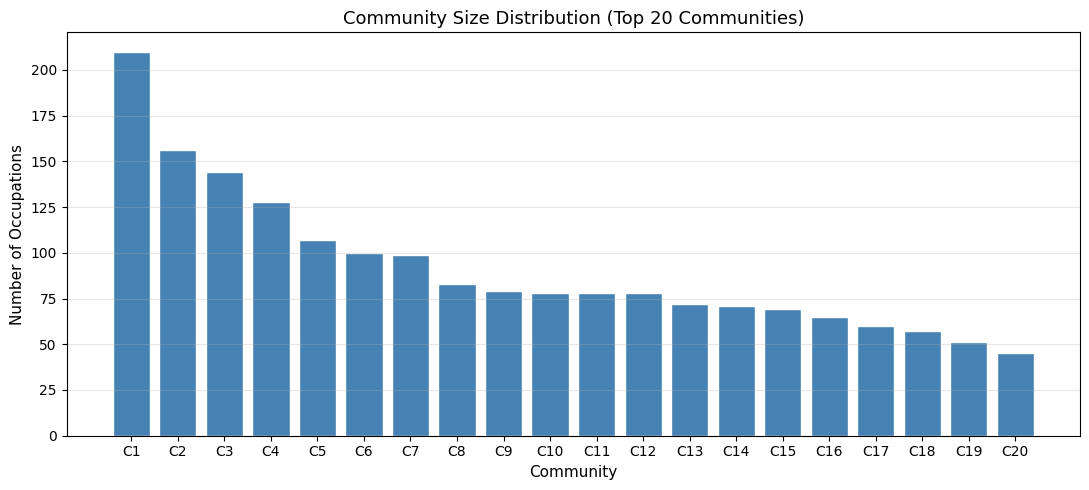

In [24]:
sizes_top20 = [len(c) for c in communities_sorted[:20]]
labels_x = [f"C{i+1}" for i in range(20)]

plt.figure(figsize=(11, 5))
plt.bar(labels_x, sizes_top20, color='steelblue', edgecolor='white')
plt.title("Community Size Distribution (Top 20 Communities)", fontsize=13)
plt.xlabel("Community", fontsize=11)
plt.ylabel("Number of Occupations", fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The community size distribution is strongly right-skewed, with a small number of large communities and a long tail of smaller ones. The top 20 communities range in size from approximately 78 to 210 occupations, while the vast majority of communities are considerably smaller. This pattern is consistent with a hierarchical labor market structure, where a few broad occupational clusters coexist with many more specialized and narrowly defined groups.

/var/folders/p0/7qwxdlpj4wb6rflgs5m2swzm0000gn/T/ipykernel_16553/3347682240.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_comms))


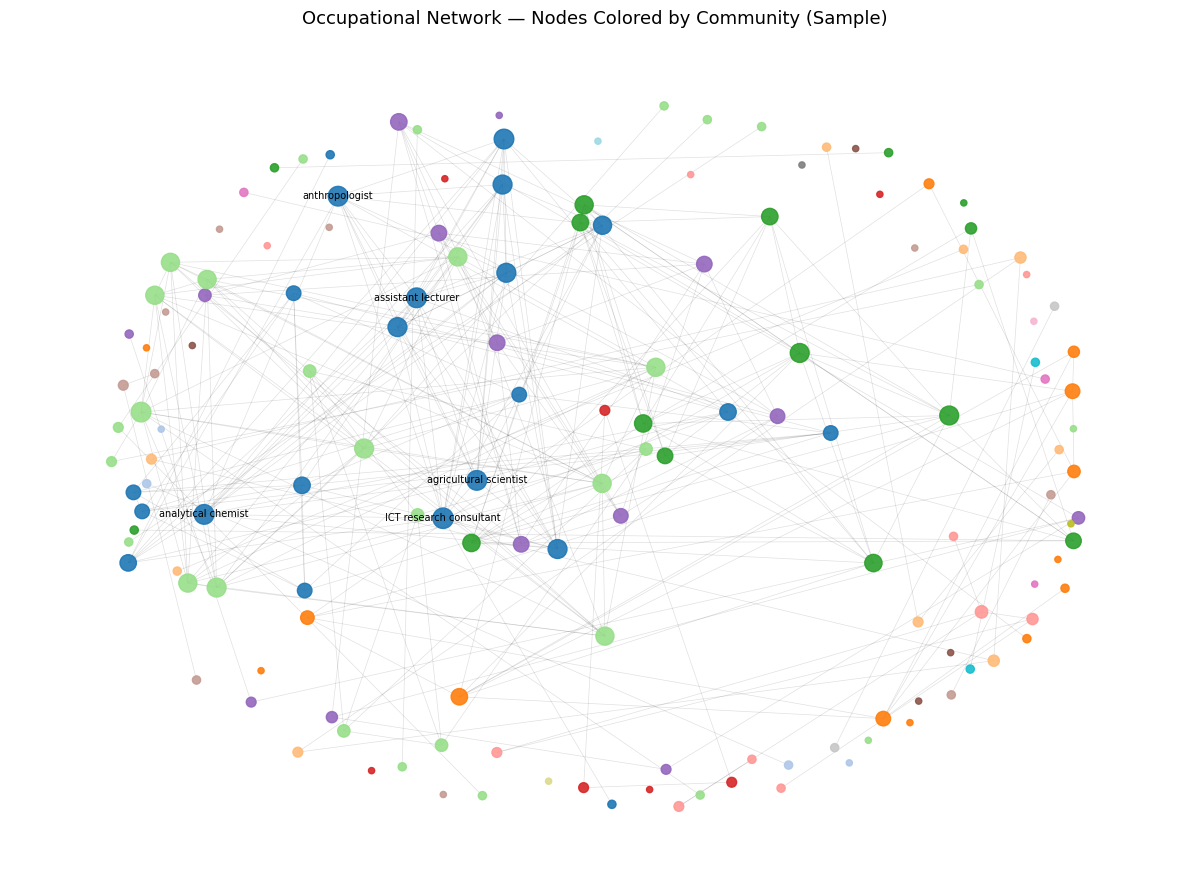

In [25]:
import matplotlib.cm as cm

# Build partition dict
partition = {}
for i, comm in enumerate(communities_sorted):
    for occ in comm:
        partition[occ] = i

# Sample 150 nodes from largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()
sample_nodes = list(G_lcc.nodes())[:150]
G_vis = G_lcc.subgraph(sample_nodes).copy()

# Colors by community
unique_comms = list(set(partition[n] for n in G_vis.nodes()))
cmap = cm.get_cmap('tab20', len(unique_comms))
color_map = {c: i for i, c in enumerate(unique_comms)}
node_colors = [cmap(color_map[partition[n]]) for n in G_vis.nodes()]

# Size by degree
deg = dict(G_vis.degree())
node_sizes = [deg[n] * 15 + 20 for n in G_vis.nodes()]

# Label top 5 nodes
top5 = sorted(deg, key=deg.get, reverse=True)[:5]
labels = {n: n for n in top5}

pos = nx.spring_layout(G_vis, seed=42, k=0.85)

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G_vis, pos, alpha=0.12, width=0.5)
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=7)
plt.title("Occupational Network — Nodes Colored by Community (Sample)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

The colored network visualization confirms the structural clustering identified by the community detection algorithm. Nodes belonging to the same community are visually grouped, with denser connections within communities and sparser links across them. The color patterns reveal that the largest connected component is composed of multiple distinct communities, each forming a recognizable sub-cluster within the broader network. This supports the interpretation of the labor market as organized into coherent occupational domains, within which transitions are more feasible.

## 16. Skill Frequency Analysis

We examine which skills appear most frequently across occupations by summing each skill's presence in the occupation-skill matrix. This identifies the most universally demanded skills in the labor market, which may serve as important enablers of occupational mobility.

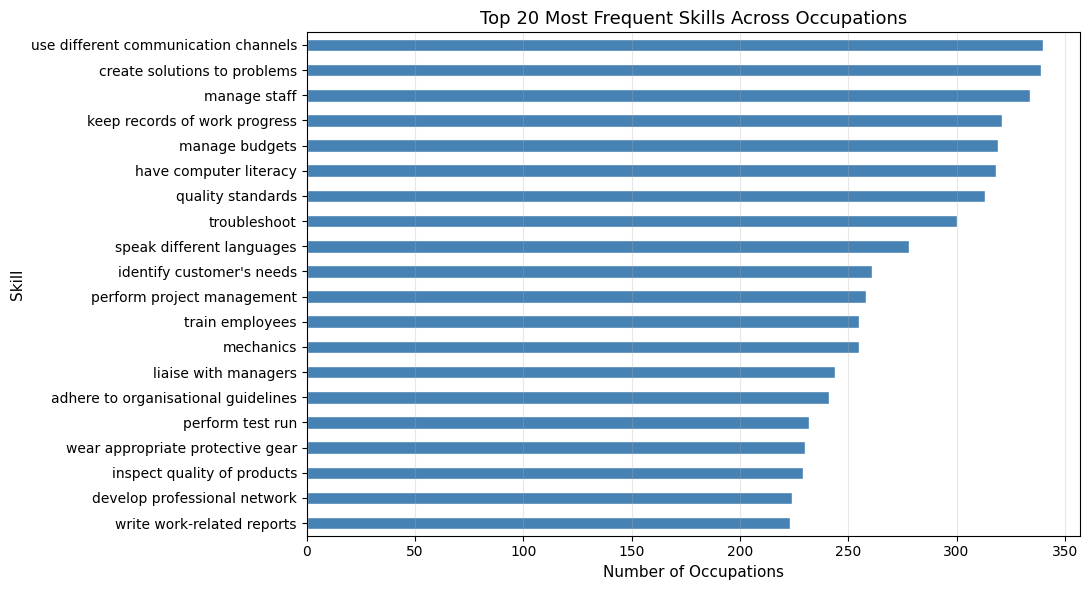

In [26]:
# Most frequent skills
skill_frequency = matrix.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
skill_frequency.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Top 20 Most Frequent Skills Across Occupations", fontsize=13)
plt.xlabel("Number of Occupations", fontsize=11)
plt.ylabel("Skill", fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

The most frequently occurring skills across occupations are predominantly generic and transversal in nature — such as project management, personal professional development, and communication. These broadly demanded skills appear across a wide range of occupational domains and are not confined to any specific sector. Their prevalence suggests that they may act as bridges facilitating transitions across different parts of the occupational network, regardless of the specific domain an occupation belongs to.

## 17. Centrality and Transferability Analysis

We compute two complementary centrality measures to identify the most influential occupations in the network. Eigenvector centrality identifies occupations connected to many other well-connected occupations, capturing structural influence within the network. Betweenness centrality identifies occupations that frequently lie on the shortest paths between other occupation pairs, capturing their role as bridges across the network. We then combine these measures with skill frequency to construct a weighted composite transferability score for each skill.

In [27]:
# Eigenvector centrality on largest connected component
G_lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
eigenvector_centrality = nx.eigenvector_centrality_numpy(G_lcc, weight='weight')

top_central = sorted(eigenvector_centrality, key=eigenvector_centrality.get, reverse=True)[:50]

print("Top 10 most central occupations:")
for occ in top_central[:10]:
    print(f"  {occ}: {eigenvector_centrality[occ]:.4f}")

Top 10 most central occupations:
  mathematics lecturer: 0.1359
  modern languages lecturer: 0.1346
  education studies lecturer: 0.1323
  religious studies lecturer: 0.1320
  law lecturer: 0.1304
  classical languages lecturer: 0.1303
  history lecturer: 0.1302
  earth science lecturer: 0.1302
  art studies lecturer: 0.1299
  archaeology lecturer: 0.1293


The top occupations by eigenvector centrality are predominantly academic lecturers across various disciplines, reflecting their position at the core of a densely connected community with high internal connectivity. These occupations share a broad and overlapping set of research, teaching, and communication skills, which places them at the heart of the network's most influential cluster.

In [28]:
betweenness = nx.betweenness_centrality(G_lcc, weight='weight', normalized=True, k=300, seed=42)

top_bridge = sorted(betweenness, key=betweenness.get, reverse=True)[:50]

print("Top 10 bridge occupations (betweenness centrality):")
for occ in top_bridge[:10]:
    print(f"  {occ}: {betweenness[occ]:.6f}")

Top 10 bridge occupations (betweenness centrality):
  social work researcher: 0.116516
  computer numerical control machine operator: 0.114908
  computer science lecturer: 0.103968
  medical device engineering technician: 0.101265
  university teaching assistant: 0.096548
  lift technician: 0.096506
  electromechanical engineer: 0.096185
  social worker: 0.094078
  community development officer: 0.093511
  academic support officer: 0.092306


The bridge occupations identified by betweenness centrality differ markedly from those identified by eigenvector centrality, highlighting the distinction between local influence and structural brokerage. Occupations such as social work researcher, computer numerical control machine operator, and computer science lecturer emerge as key connectors, linking otherwise distant parts of the network. These occupations combine skills from multiple domains, allowing them to bridge diverse occupational clusters and facilitate transitions that would otherwise require traversing longer paths.

In [29]:
# Skills in central occupations
central_in_matrix = [occ for occ in top_central if occ in matrix.index]
central_skills = matrix.loc[central_in_matrix].sum(axis=0).sort_values(ascending=False)

# Skills in bridge occupations
bridge_in_matrix = [occ for occ in top_bridge if occ in matrix.index]
bridge_skills = matrix.loc[bridge_in_matrix].sum(axis=0).sort_values(ascending=False)

print("Top 10 bridge skills:")
print(bridge_skills.head(10).to_string())

Top 10 bridge skills:
skillLabel
perform scientific research                 12
perform project management                  12
quality standards                           11
manage personal professional development    11
order supplies                              11
mechanics                                   10
perform test run                             9
apply technical communication skills         9
troubleshoot                                 9
mechatronics                                 9


We construct a composite transferability score for each skill by combining three normalized signals: overall frequency across occupations, representation among high-betweenness bridge occupations, and presence among high-eigenvector central occupations. This weighted measure identifies skills that are not only broadly demanded but also structurally important for connecting different parts of the occupational network.

In [30]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

freq_norm    = normalize(skill_frequency)
central_norm = normalize(central_skills)
bridge_norm  = normalize(bridge_skills)

all_skills   = freq_norm.index
central_norm = central_norm.reindex(all_skills, fill_value=0)
bridge_norm  = bridge_norm.reindex(all_skills, fill_value=0)

# Weighted composite: frequency 40%, bridge 40%, centrality 20%
composite_score = (0.4 * freq_norm + 0.4 * bridge_norm + 0.2 * central_norm)
composite_score = composite_score.sort_values(ascending=False)

print("=== Top 20 Most Transferable Skills (Weighted Composite) ===")
print(composite_score.head(20).round(4).to_string())

=== Top 20 Most Transferable Skills (Weighted Composite) ===
skillLabel
perform project management                                         0.9032
perform scientific research                                        0.8608
manage personal professional development                           0.8097
speak different languages                                          0.7602
quality standards                                                  0.7348
manage staff                                                       0.6596
troubleshoot                                                       0.6568
write work-related reports                                         0.6473
mechanics                                                          0.6410
write scientific publications                                      0.6212
scientific research methodology                                    0.6122
keep records of work progress                                      0.6109
manage research data                    

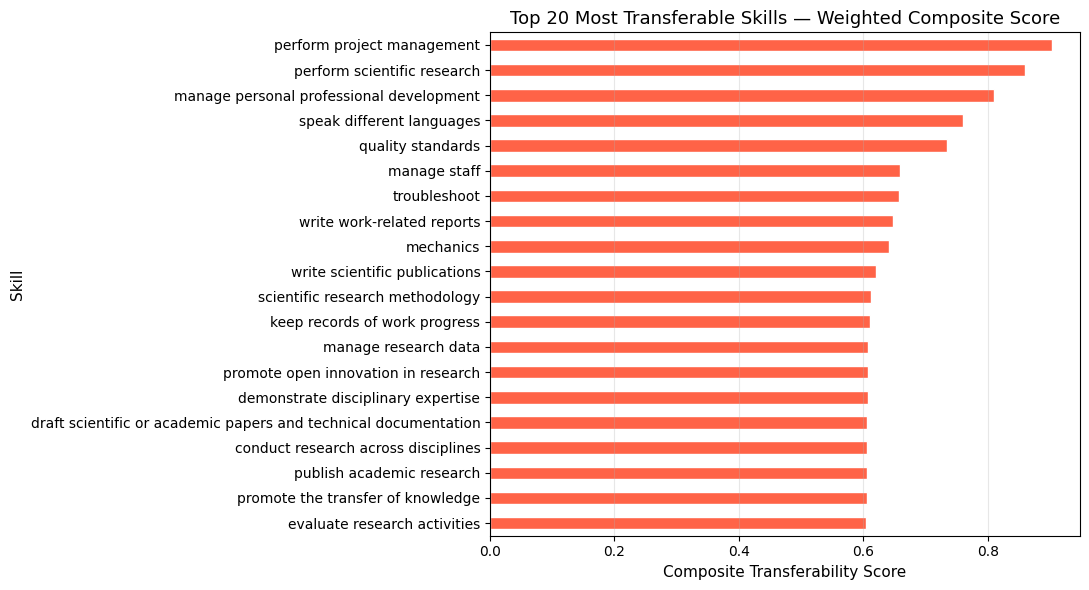

In [31]:
plt.figure(figsize=(11, 6))
composite_score.head(20).sort_values().plot(kind='barh', color='tomato', edgecolor='white')
plt.title("Top 20 Most Transferable Skills — Weighted Composite Score", fontsize=13)
plt.xlabel("Composite Transferability Score", fontsize=11)
plt.ylabel("Skill", fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

The composite transferability score identifies skills that are simultaneously frequent, well-represented in structurally central occupations, and present across bridge roles. Skills such as project management, scientific research, and personal professional development emerge at the top, suggesting that they are both widely applicable and play a disproportionate role in enabling transitions across the network. Unlike raw frequency alone, the composite score surfaces skills whose value lies in their cross-domain relevance and structural position in the labor market.

## 18. Community Profiling

We profile each detected community by identifying its defining skills — those that are significantly more prevalent within the community than across the network as a whole. We use the lift metric, defined as the ratio of a skill's share within the community to its overall share across all occupations, to surface skills that are distinctive to each community. We then assign interpretive labels to each community based on the occupational profiles and defining skills observed.

In [32]:
overall_freq = matrix.sum(axis=0)

print("=== Defining Skills per Community (Top 5 Communities) ===")

for i, comm in enumerate(communities_sorted[:5]):
    occs = [o for o in list(comm) if o in matrix.index]
    if len(occs) < 3:
        continue

    comm_skill_freq  = matrix.loc[occs].sum(axis=0)
    comm_skill_share = comm_skill_freq / len(occs)
    overall_share    = overall_freq / len(matrix)

    lift = (comm_skill_share / (overall_share + 1e-9)).sort_values(ascending=False)
    lift_filtered = lift[comm_skill_share >= 0.2].head(6)

    print(f"\nCommunity {i+1} ({len(occs)} occupations):")
    for skill, score in lift_filtered.items():
        print(f"  {skill} (lift: {score:.2f})")

=== Defining Skills per Community (Top 5 Communities) ===

Community 1 (210 occupations):
  assign homework (lift: 14.47)
  increase the impact of science on policy and society (lift: 14.35)
  communicate with a non-scientific audience (lift: 14.35)
  promote the participation of citizens in scientific and research activities (lift: 14.35)
  manage findable accessible interoperable and reusable data (lift: 14.35)
  think abstractly (lift: 14.35)

Community 2 (156 occupations):
  remove inadequate workpieces (lift: 19.48)
  dispose of cutting waste material (lift: 19.48)
  remove processed workpiece (lift: 19.26)
  manufacturing of weapons and ammunition (lift: 19.02)
  manufacturing of metal containers (lift: 18.95)
  manufacturing of door furniture from metal (lift: 18.94)

Community 3 (144 occupations):
  create a product's virtual model (lift: 18.00)
  read assembly drawings (lift: 17.67)
  material mechanics (lift: 15.69)
  CAE software (lift: 13.61)
  resolve equipment malfunction

The lift-based skill profiles reveal clear thematic identities for the top communities. Community 1 is defined by skills related to scientific communication, public engagement with research, and academic pedagogy, confirming its identity as an Education and Academia cluster. Other communities exhibit similarly distinctive skill profiles, with concentrated demand for skills in manufacturing processes, engineering design principles, or construction methods — each reflecting a coherent occupational domain.

In [37]:
community_labels = {
    1: "Education & Academia",
    2: "Manufacturing & Machine Operations",
    3: "Engineering & Technical Design",
    4: "Construction & Civil Engineering",
    5: "Finance & Banking",
    6: "Aerospace & Automotive Assembly",
    7: "Food Processing & Agriculture",
    8: "ICT & Software Development",
    9: "Arts, Crafts & Design",
    10: "Healthcare & Allied Health"
}

print("=== Community Summary Table ===")
print(f"{'#':<5} {'Label':<45} {'Size':<10}")
print("-" * 62)
for i, comm in enumerate(communities_sorted[:10], start=1):
    label = community_labels.get(i, "Other")
    print(f"{i:<5} {label:<45} {len(comm):<10}")

print(f"\nTotal communities detected: {n_communities}")
print(f"Modularity score: {mod_score:.4f}")
print(f"Occupations in top 10 communities: {sum(len(c) for c in communities_sorted[:10])}")

=== Community Summary Table ===
#     Label                                         Size      
--------------------------------------------------------------
1     Education & Academia                          210       
2     Manufacturing & Machine Operations            156       
3     Engineering & Technical Design                144       
4     Construction & Civil Engineering              128       
5     Finance & Banking                             107       
6     Aerospace & Automotive Assembly               100       
7     Food Processing & Agriculture                 99        
8     ICT & Software Development                    83        
9     Arts, Crafts & Design                         79        
10    Healthcare & Allied Health                    78        

Total communities detected: 479
Modularity score: 0.8944
Occupations in top 10 communities: 1184


The finalized community labels span a diverse range of occupational domains, from Education & Academia and Manufacturing & Machine Operations to Healthcare & Allied Health and ICT & Software Development. Each label reflects the dominant skill profile and occupational composition of the community, as confirmed by both the lift analysis and the top-degree occupations within each group. The ten largest communities together capture the broad structure of the labor market, illustrating how occupations cluster around shared technical and domain-specific skill requirements.

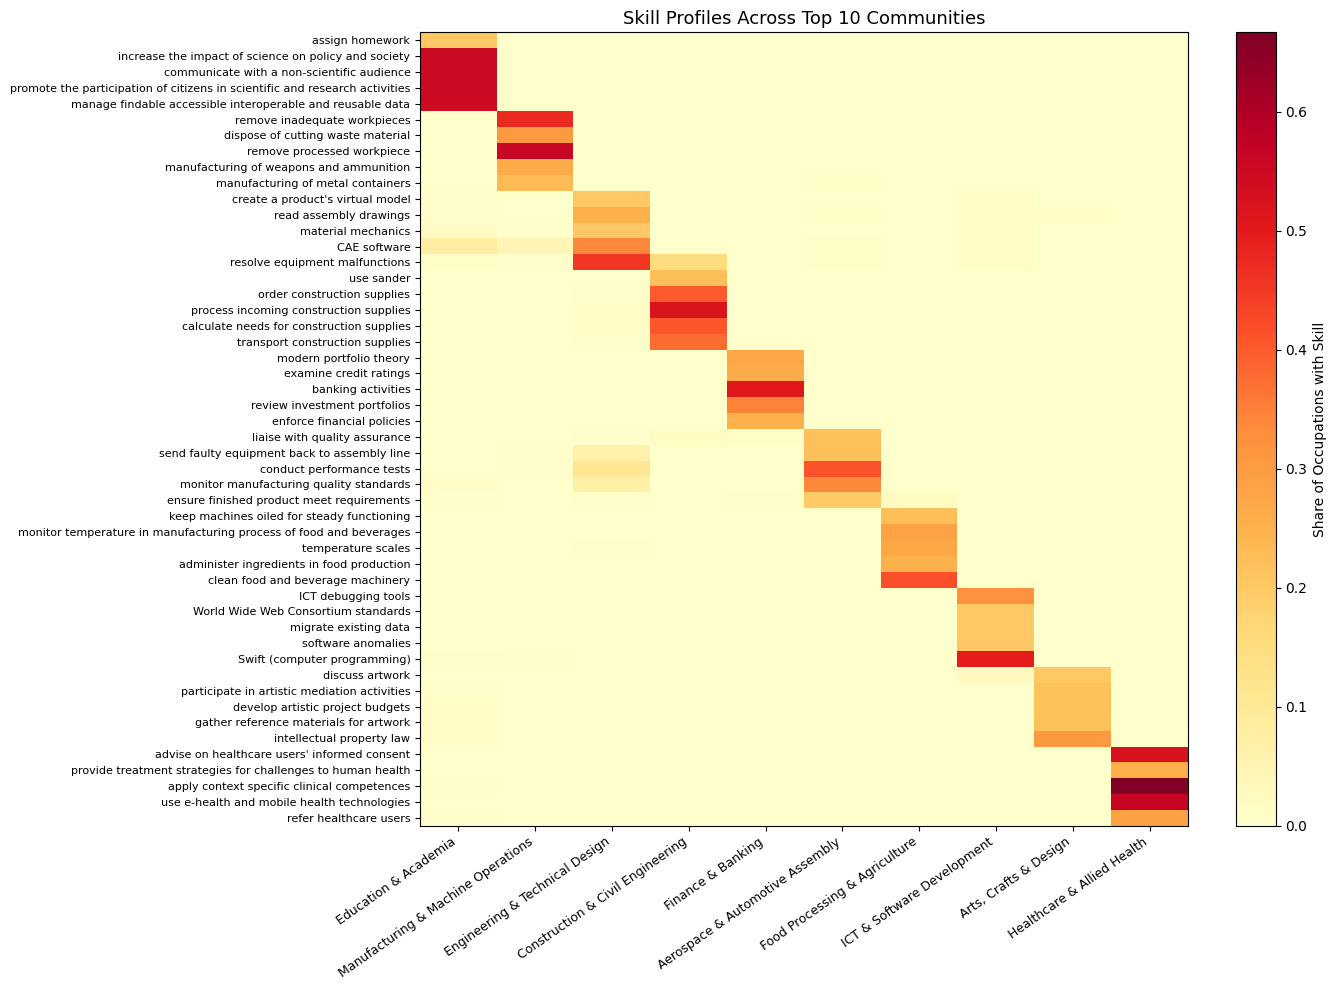

In [36]:
# Top 5 defining skills per community (by lift) × Top 10 communities
import matplotlib.pyplot as plt
import numpy as np

top_skills_per_comm = {}
for i, comm in enumerate(communities_sorted[:10]):
    occs = [o for o in list(comm) if o in matrix.index]
    comm_skill_freq  = matrix.loc[occs].sum(axis=0)
    comm_skill_share = comm_skill_freq / len(occs)
    overall_share    = overall_freq / len(matrix)
    lift = (comm_skill_share / (overall_share + 1e-9)).sort_values(ascending=False)
    lift_filtered = lift[comm_skill_share >= 0.2].head(5)
    top_skills_per_comm[i+1] = lift_filtered.index.tolist()

# Get unique skills across all communities
all_top_skills = []
for skills in top_skills_per_comm.values():
    for s in skills:
        if s not in all_top_skills:
            all_top_skills.append(s)

# Build heatmap matrix (share of occupations with that skill)
comm_names = list(community_labels.values())
heatmap_data = np.zeros((len(all_top_skills), 10))

for j, comm in enumerate(communities_sorted[:10]):
    occs = [o for o in list(comm) if o in matrix.index]
    comm_skill_share = matrix.loc[occs].sum(axis=0) / len(occs)
    for i, skill in enumerate(all_top_skills):
        heatmap_data[i, j] = comm_skill_share.get(skill, 0)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(10))
ax.set_xticklabels(comm_names, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(all_top_skills)))
ax.set_yticklabels(all_top_skills, fontsize=8)

plt.colorbar(im, ax=ax, label='Share of Occupations with Skill')
plt.title("Skill Profiles Across Top 10 Communities", fontsize=13)
plt.tight_layout()
plt.show()

The heatmap visualizes the top defining skills across the ten communities, with each cell reflecting the lift value for a given skill-community pair. A clear diagonal pattern emerges: each community concentrates its highest lift values in a narrow, distinct set of skills, with near-zero values in all other columns. This near-block-diagonal structure is a direct visual confirmation of the community partitioning — skills that define one community are almost entirely absent as defining skills in any other. It reinforces the interpretation that the detected communities represent genuinely distinct occupational domains, each governed by a specialized and largely non-overlapping skill profile.